In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt 


In [4]:
df=pd.read_csv(r'D:\fcai\data analysis - depi\tec\python\car_prices.csv')

In [91]:
df.info()

<class 'pandas.DataFrame'>
Index: 484838 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          484838 non-null  int64  
 1   make          484838 non-null  str    
 2   model         484838 non-null  str    
 3   trim          484838 non-null  str    
 4   body          484838 non-null  str    
 5   transmission  484838 non-null  str    
 6   vin           484838 non-null  str    
 7   state         484838 non-null  str    
 8   condition     484838 non-null  float64
 9   odometer      484838 non-null  float64
 10  color         484838 non-null  str    
 11  interior      484838 non-null  str    
 12  seller        484838 non-null  str    
 13  mmr           484838 non-null  float64
 14  sellingprice  484838 non-null  float64
 15  saledate      484838 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 62.9 MB


In [9]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='str')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [13]:
df=df.dropna(subset=["make","model"])

In [36]:
df=df.dropna(subset=["vin","saledate"])

In [37]:
df.isnull().sum()

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64

In [28]:
df["transmission"].unique()
df["transmission"]=df.loc[:,"transmission"].replace({
    'Sedan':'automatic',
    'sedan':'manual'}
)

In [17]:
df["condition"]=df["condition"].fillna(df["condition"].mean())

In [21]:
df=df.dropna(subset=["transmission"])

In [33]:
numb_col=["odometer","mmr","sellingprice"]
for col in numb_col:
    df[col]=df[col].fillna(df[col].mean())

In [34]:
numb_col=["trim","color","interior","body"]
for col in numb_col:
    df[col]=df[col].fillna(df[col].mode()[0])

In [39]:
df

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558831,2011,BMW,5 Series,528i,Sedan,automatic,wbafr1c53bc744672,fl,39.0,66403.0,white,brown,lauderdale imports ltd bmw pembrok pines,20300.0,22800.0,Tue Jul 07 2015 06:15:00 GMT-0700 (PDT)
558833,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)


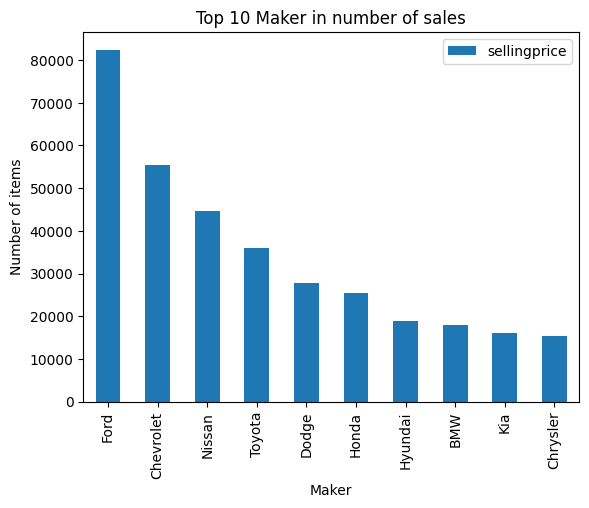

In [73]:
#what is the top 10 maker(factories) in number of sales?
df.pivot_table(
    values= 'sellingprice',
    index='make',
    aggfunc='count'
).sort_values(by=['sellingprice'] ,ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Maker in number of sales")
plt.ylabel("Number of items")
plt.xlabel("Maker")
plt.show()


In [ ]:
# What is the top 10 maker(factories) in the amount of sales?
df.pivot_table(
    values= 'sellingprice',
    index='make',
    aggfunc='sum'
).sort_values(by=['sellingprice'] ,ascending=False).head(10)


,sellingprice
make,
Ford,1.212861e+09
Chevrolet,6.508466e+08
Nissan,5.217652e+08
Toyota,4.442907e+08
BMW,3.794029e+08
Mercedes-Benz,3.050742e+08
Dodge,3.012643e+08
Infiniti,2.892816e+08
Honda,2.747625e+08


In [59]:
# What is the top 10 models in the amount of sales?
df.pivot_table(
    values= 'sellingprice',
    index=['make','model'],
    aggfunc='sum'
).sort_values(by=['sellingprice'] ,ascending=False).head(10)

sellingprice
make      model                       
Ford      F-150            236979858.0
Nissan    Altima           186410250.0
Ford      Escape           153158751.0
          Fusion           150567020.0
Infiniti  G Sedan          138577506.0
Toyota    Camry            127185457.0
Ford      Explorer         124276092.0
BMW       3 Series         122649660.0
Chevrolet Silverado 1500    97649896.0
Ford      Edge              96592907.0

In [69]:
# What is the top 5 models in the amount of sales in number 1 maker? -> how to do it for each maker
df_Maker_filter=df[(df['make']=='Ford')]
df_Maker_filter.pivot_table(
    values= 'sellingprice',
    index=['make','model'],
    aggfunc='sum'
).sort_values(by=['sellingprice'] ,ascending=False).head(5)

sellingprice
make model                 
Ford F-150      236979858.0
     Escape     153158751.0
     Fusion     150567020.0
     Explorer   124276092.0
     Edge        96592907.0

In [ ]:
# What is the top 10 states in the amount of sales?
df.pivot_table(
    values= 'sellingprice',
    index=['state'],
    aggfunc='sum'
).sort_values(by=['sellingprice'] ,ascending=False).head(10)

,sellingprice
state,
fl,1.091076e+09
ca,1.001288e+09
tx,5.770926e+08
ga,4.016816e+08
pa,3.421843e+08
il,3.371995e+08
tn,3.346820e+08
nj,3.173324e+08
oh,2.957982e+08


In [ ]:
# What is the top 10 saller in the amount of sales?
df.pivot_table(
    values= 'sellingprice',
    index=['seller'],
    aggfunc='sum'
).sort_values(by=['sellingprice'] ,ascending=False).head(10)

,sellingprice
seller,
ford motor credit company llc,315493525.0
the hertz corporation,225285565.0
nissan-infiniti lt,217041910.0
nissan infiniti lt,203191221.0
avis corporation,185764630.0
financial services remarketing (lease),142627575.0
mercedes-benz financial services,122514150.0
santander consumer,114304240.0
enterprise veh exchange/rental,105133336.0


In [77]:
# What is the top 10 saller in the amount of sales?
df.pivot_table(
    values= 'sellingprice',
    index=['state','seller'],
    aggfunc='sum'
).sort_values(by=['sellingprice'] ,ascending=False).head(10)

sellingprice
state seller                                              
ca    financial services remarketing (lease)    69047925.0
      nissan infiniti lt                        60796450.0
il    ford motor credit company llc             57457075.0
fl    lexus financial services                  54807700.0
      tdaf remarketing                          47469400.0
      nissan-infiniti lt                        47308600.0
tx    avis corporation                          38754050.0
ca    mercedes-benz financial services          38097200.0
fl    world omni financial corporation          37983550.0
      nissan infiniti lt                        37812600.0

In [ ]:
# What is the top 5 years in the amount of sales?
df.pivot_table(
    values= 'sellingprice',
    index=['year'],
    aggfunc='sum'
).sort_values(by=['sellingprice'] ,ascending=False).head(5)

,sellingprice
year,
2013,1.523088e+09
2012,1.447287e+09
2014,1.397467e+09
2011,6.577142e+08
2010,2.830052e+08


In [82]:
# What is the top 5 colors in the amount of sales?
df.pivot_table(
    values= 'sellingprice',
    index=['color'],
    aggfunc='sum'
).sort_values(by=['sellingprice'] ,ascending=False).head(5)

,sellingprice
color,
black,1.474385e+09
white,1.342054e+09
gray,9.967247e+08
silver,8.562749e+08
blue,5.045606e+08


In [83]:
# What is the top 5 colors in the amount of sales?
df.pivot_table(
    values= 'sellingprice',
    index=['make','color'],
    aggfunc='sum'
).sort_values(by=['sellingprice'] ,ascending=False).head(5)

sellingprice
make      color              
Ford      white   277809184.0
          black   219643487.0
          —       170380007.0
Chevrolet white   154419318.0
Ford      gray    134410082.0

In [ ]:
#we have problem in colors
df['color'].unique()

<StringArray>
[    'white',      'gray',     'black',       'red',    'silver',      'blue',
     'brown',     'beige',    'purple',  'burgundy',         '—',      'gold',
    'yellow',     'green',  'charcoal',    'orange', 'off-white', 'turquoise',
      'pink',      'lime',      '4802',      '9410',      '1167',      '2172',
     '14872',     '12655',     '15719',      '6388',     '16633',     '11034',
      '6864',       '339',     '18384',      '9887',      '9837',     '20627',
       '721',      '6158',      '5705',     '18561',      '2846',      '5001']
Length: 42, dtype: str

<Axes: >

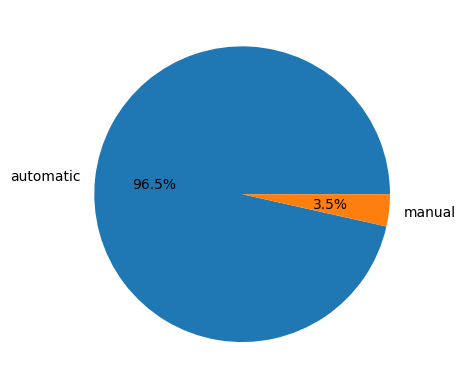

In [ ]:
# What is the ratio between automatic and manual?
(df['transmission'].value_counts()/484838 ).plot(kind='pie', autopct='%1.1f%%')

In [97]:
df.info()

<class 'pandas.DataFrame'>
Index: 484838 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          484838 non-null  int64  
 1   make          484838 non-null  str    
 2   model         484838 non-null  str    
 3   trim          484838 non-null  str    
 4   body          484838 non-null  str    
 5   transmission  484838 non-null  str    
 6   vin           484838 non-null  str    
 7   state         484838 non-null  str    
 8   condition     484838 non-null  float64
 9   odometer      484838 non-null  float64
 10  color         484838 non-null  str    
 11  interior      484838 non-null  str    
 12  seller        484838 non-null  str    
 13  mmr           484838 non-null  float64
 14  sellingprice  484838 non-null  float64
 15  saledate      484838 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 62.9 MB


In [99]:
df['sellingprice'].corr(df['odometer'])

np.float64(-0.5814184188834678)